In [1]:
# Load the training dataset
import pandas as pd
train_df = pd.read_csv('clean_train_dataset.csv')
print('Training dataset loaded. Shape:', train_df.shape)
train_df.head()

Training dataset loaded. Shape: (81474, 39)


,number_inpatient,time_in_hospital,number_emergency,number_outpatient,num_medications,num_lab_procedures,diabetesMed,insulin,metformin,admission_type_id,...,diag_1_Respiratory,diag_2_Circulatory,diag_2_Diabetes,diag_2_Digestive,diag_2_Genitourinary,diag_2_Injury,diag_2_Musculoskeletal,diag_2_Neoplasms,diag_2_Other,diag_2_Respiratory
0,0,1,0,0,1,41,0,0,0,6,...,0,0,0,0,0,0,0,0,1,0
1,0,3,0,0,18,59,1,3,0,1,...,0,0,1,0,0,0,0,0,0,0
2,1,2,0,2,13,11,1,0,0,1,...,0,0,1,0,0,0,0,0,0,0
3,0,2,0,0,16,44,1,3,0,1,...,0,0,1,0,0,0,0,0,0,0
4,0,3,0,0,16,31,1,2,0,2,...,0,1,0,0,0,0,0,0,0,0


Class distribution:
readmitted
0    72286
1     9188
Name: count, dtype: int64


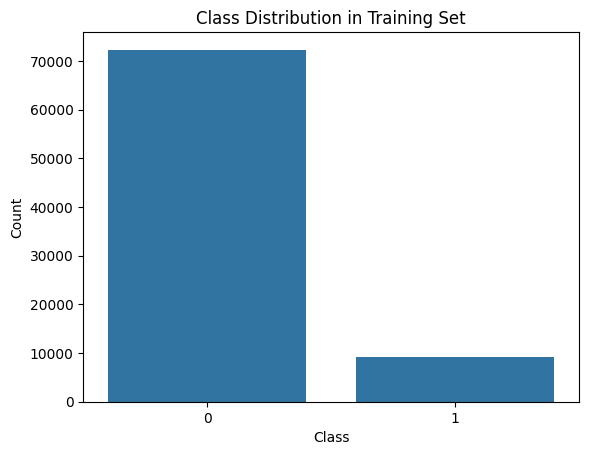

In [2]:
# Visualize the class (target variable) distribution
import matplotlib.pyplot as plt
import seaborn as sns

# Replace 'readmitted' with your actual target column name if different
class_col = 'readmitted'
class_counts = train_df[class_col].value_counts()
print('Class distribution:')
print(class_counts)

sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title('Class Distribution in Training Set')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

In [3]:
# Downsample class 0 to match class 1 (9188 samples) using random sampling
from sklearn.utils import resample

# Separate majority and minority classes
majority = train_df[train_df['readmitted'] == 0]
minority = train_df[train_df['readmitted'] == 1]

# Downsample majority class
majority_downsampled = resample(majority, 
                                replace=False,    # sample without replacement
                                n_samples=9188,    # match minority class
                                random_state=42)   # reproducible

# Combine minority class with downsampled majority class
balanced_df = pd.concat([majority_downsampled, minority])

# Shuffle the resulting dataframe
balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Check new class distribution
print('Balanced class distribution:')
print(balanced_df['readmitted'].value_counts())

Balanced class distribution:
readmitted
0    9188
1    9188
Name: count, dtype: int64


Balanced class distribution:
readmitted
0    9188
1    9188
Name: count, dtype: int64


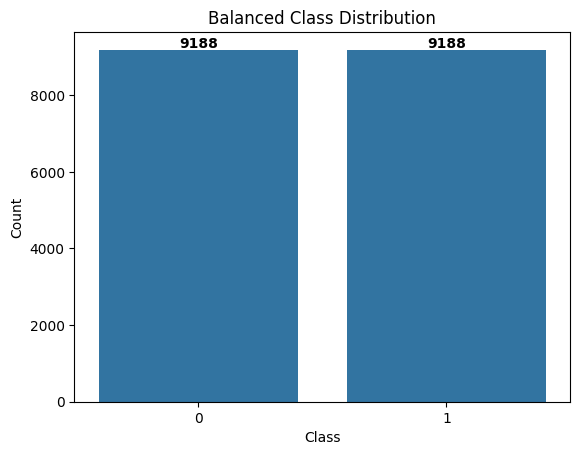

In [4]:
# Visualize the balanced class distribution with numbers
balanced_counts = balanced_df['readmitted'].value_counts()
print('Balanced class distribution:')
print(balanced_counts)

ax = sns.barplot(x=balanced_counts.index, y=balanced_counts.values)
for i, v in enumerate(balanced_counts.values):
    ax.text(i, v + 50, str(v), color='black', ha='center', fontweight='bold')
plt.title('Balanced Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

In [5]:
# Save the balanced dataset to a new CSV file
balanced_df.to_csv('balance_classes_training_dataset.csv', index=False)
print('Balanced training dataset saved as balance_classes_training_dataset.csv')

Balanced training dataset saved as balance_classes_training_dataset.csv
